In [ ]:
from google.colab import files

uploaded = files.upload()

Saving MySensorData - Sheet1.csv to MySensorData - Sheet1.csv


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("MySensorData - Sheet1.csv")

df.columns = df.columns.str.replace(r'[\"\n\s]', '', regex=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.replace(r'[\"\n]', '', regex=True).str.strip()


df["ScannedCount"] = pd.to_numeric(df["ScannedCount"], errors='coerce')
df["TotalScans"] = pd.to_numeric(df["TotalScans"], errors='coerce')


df["StartTime"] = pd.to_datetime(df["StartTime"], errors='coerce')
df["EndTime"] = pd.to_datetime(df["EndTime"], errors='coerce')

df = df.dropna(subset=["StartTime", "ScannedCount"]).reset_index(drop=True)

df = df.sort_values(by="StartTime").reset_index(drop=True)


df["hour"] = df["StartTime"].dt.hour
df["day_of_week"] = df["StartTime"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["prev_scanned_count"] = df["ScannedCount"].shift(1)
df = df.dropna(subset=["prev_scanned_count"]).reset_index(drop=True)
df["LocationID"] = df["LocationID"].astype("category")

feature_cols = ["LocationID", "hour", "day_of_week", "is_weekend", "prev_scanned_count", "TotalScans"]
X = df[feature_cols]
y = df["ScannedCount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=150,     # Slightly increased for your full dataset
    learning_rate=0.05,
    num_leaves=31,        # Default robust setting for standard leaf growth
    max_depth=6,          # Deep enough to capture traffic spikes but keeps it stable
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*40)
print("Model Training Complete on Full Dataset!")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Accuracy Score: {r2:.2f}")
print("="*40)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 1539, number of used features: 5
[LightGBM] [Info] Start training from score 49.641975
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv("MySensorData - Sheet1.csv")

df.columns = df.columns.str.replace(r'[\"\n\s]', '', regex=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.replace(r'[\"\n]', '', regex=True).str.strip()

df["ScannedCount"] = pd.to_numeric(df["ScannedCount"], errors='coerce')
df["TotalScans"] = pd.to_numeric(df["TotalScans"], errors='coerce')
df["StartTime"] = pd.to_datetime(df["StartTime"], errors='coerce')
df["EndTime"] = pd.to_datetime(df["EndTime"], errors='coerce')

df = df.dropna(subset=["StartTime", "ScannedCount"]).sort_values(by="StartTime").reset_index(drop=True)

# A. Base Time Features
df["Hour"] = df["StartTime"].dt.hour
df["DayOfWeek"] = df["StartTime"].dt.dayofweek
df["DayName"] = df["StartTime"].dt.day_name()
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
df["Date"] = df["StartTime"].dt.date

# B. Peak-Hour Indicators (Assuming high-traffic slots are 8-11 AM & 5-9 PM based on typical curves)
df["IsPeakHour"] = (((df["Hour"] >= 8) & (df["Hour"] <= 11)) | ((df["Hour"] >= 17) & (df["Hour"] <= 21))).astype(int)

# C. Lag Features (t-1 to t-k, choosing k=3 for the past three 5-minute blocks)
for k in range(1, 4):
    df[f"Lag_{k}"] = df["ScannedCount"].shift(k)

# D. Rolling Statistics (Using a window of 3 intervals ~ 15 minutes)
df["Rolling_Mean_3"] = df["ScannedCount"].rolling(window=3).mean()
df["Rolling_Std_3"] = df["ScannedCount"].rolling(window=3).std()

# E. Inter-Arrival Time Distributions (Time delta between consecutive logging events in seconds)
df["InterArrivalTime_Sec"] = df["StartTime"].diff().dt.total_seconds()

# Clear empty rows created by lag/rolling shifts
df_clean = df.dropna().reset_index(drop=True)
print(f"Data ready! Shape after engineering features: {df_clean.shape}")
df_clean.head(3)

Data ready! Shape after engineering features: (1922, 17)


,LocationID,StartTime,EndTime,ScannedCount,TotalScans,Hour,DayOfWeek,DayName,IsWeekend,Date,IsPeakHour,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_Std_3,InterArrivalTime_Sec
0,PS-0801,2026-05-24 00:18:38,2026-05-24 00:23:21,3,15,0,6,Sunday,1,2026-05-24,0,5.0,3.0,4.0,3.666667,1.154701,287.0
1,PS-0801,2026-05-24 00:24:06,2026-05-24 00:28:38,3,14,0,6,Sunday,1,2026-05-24,0,3.0,5.0,3.0,3.666667,1.154701,328.0
2,PS-0801,2026-05-24 00:29:12,2026-05-24 00:33:55,2,15,0,6,Sunday,1,2026-05-24,0,3.0,3.0,5.0,2.666667,0.577350,306.0


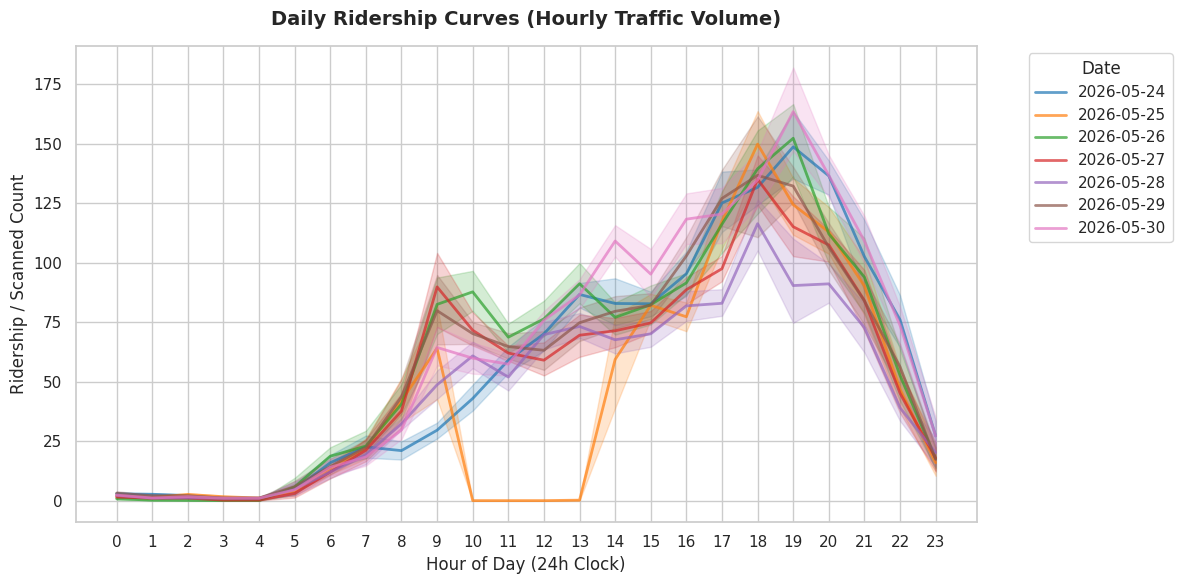

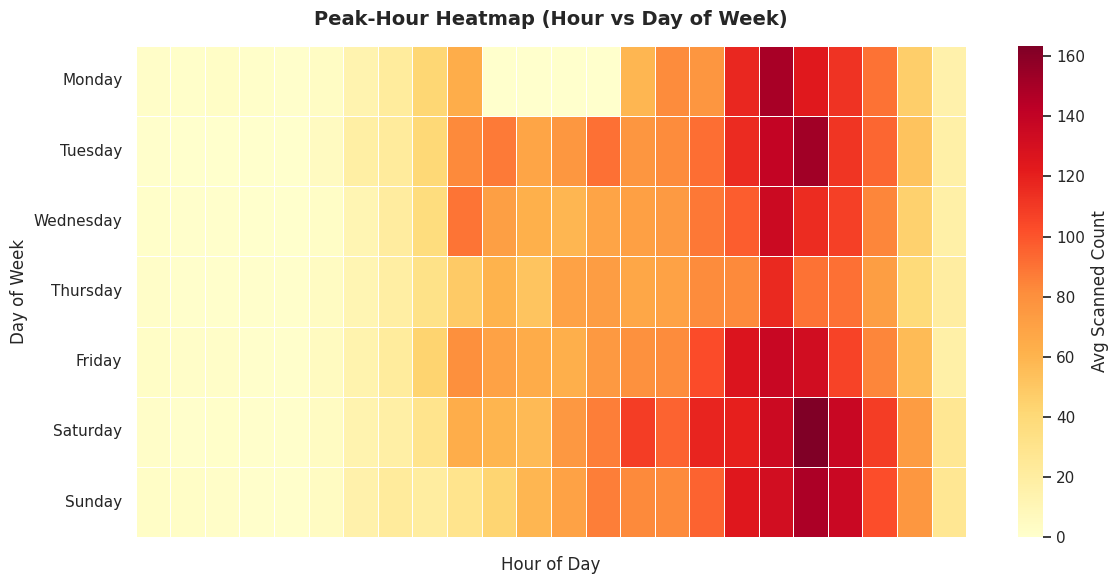

/tmp/ipykernel_5938/1932841587.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="IsWeekend", y="ScannedCount", ax=axes[0], palette="Set2")
/tmp/ipykernel_5938/1932841587.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Weekday", "Weekend"])
/tmp/ipykernel_5938/1932841587.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_clean, x="Hour", y="ScannedCount", hue="DayType", ax=axes[1], marker='o', palette="Set1", ci=None)


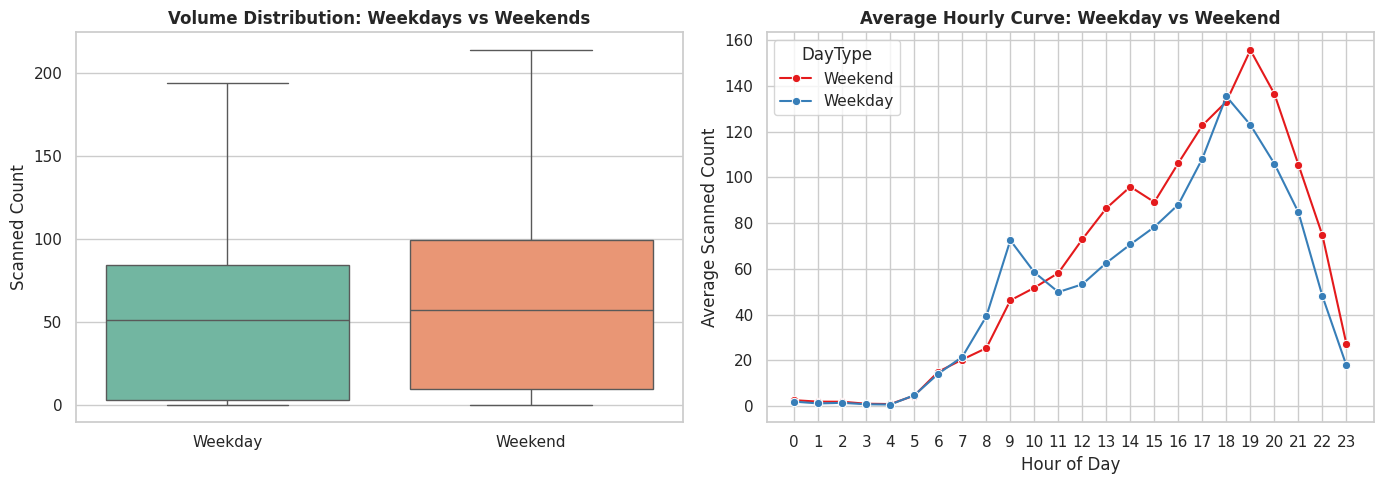

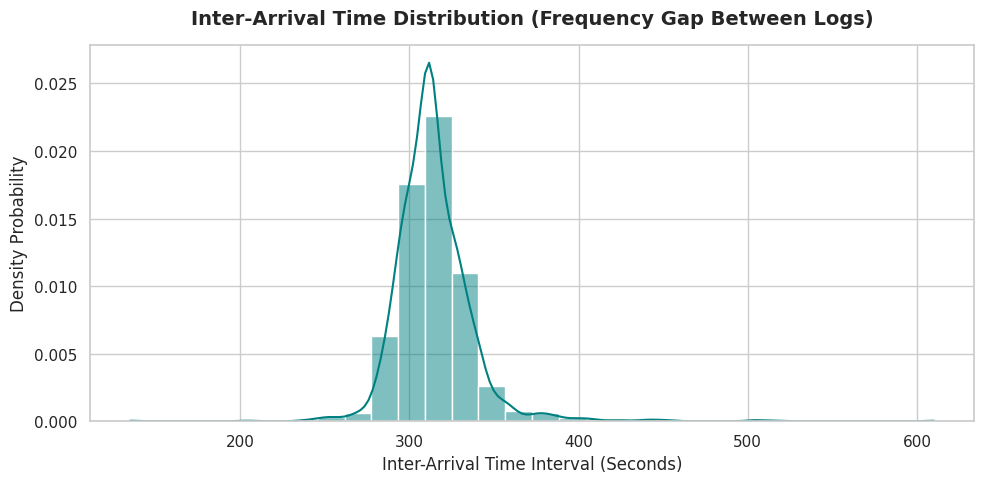

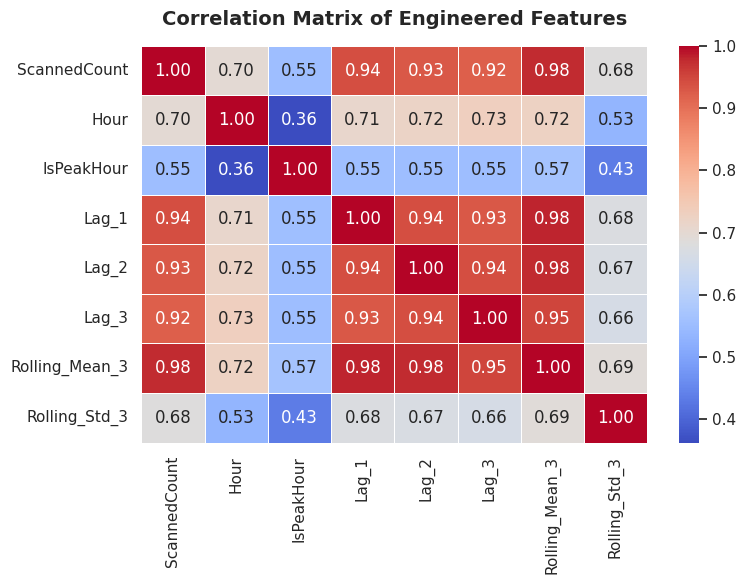

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_clean, x="Hour", y="ScannedCount", hue="Date", palette="tab10", alpha=0.7, linewidth=2)
plt.title("Daily Ridership Curves (Hourly Traffic Volume)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Hour of Day (24h Clock)", fontsize=12)
plt.ylabel("Ridership / Scanned Count", fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title="Date", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
# Pivot data to matrix structure: Rows = Days of Week, Columns = Hours
pivot_df = df_clean.groupby(["DayName", "Hour"])["ScannedCount"].mean().unstack(level=-1)
# Order week days logically
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_df = pivot_df.reindex(days_order)

sns.heatmap(pivot_df, cmap="YlOrRd", annot=False, linewidths=0.5, cbar_kws={'label': 'Avg Scanned Count'})
plt.title("Peak-Hour Heatmap (Hour vs Day of Week)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="IsWeekend", y="ScannedCount", ax=axes[0], palette="Set2")
axes[0].set_xticklabels(["Weekday", "Weekend"])
axes[0].set_title("Volume Distribution: Weekdays vs Weekends", fontsize=12, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Scanned Count")

df_clean["DayType"] = df_clean["IsWeekend"].map({0: "Weekday", 1: "Weekend"})
sns.lineplot(data=df_clean, x="Hour", y="ScannedCount", hue="DayType", ax=axes[1], marker='o', palette="Set1", ci=None)
axes[1].set_title("Average Hourly Curve: Weekday vs Weekend", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Average Scanned Count")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

active_intervals = df_clean[df_clean["InterArrivalTime_Sec"] < 1800] # under 30 mins

sns.histplot(active_intervals["InterArrivalTime_Sec"], kde=True, color="teal", bins=30, stat="density")
plt.title("Inter-Arrival Time Distribution (Frequency Gap Between Logs)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Inter-Arrival Time Interval (Seconds)", fontsize=12)
plt.ylabel("Density Probability", fontsize=12)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
engineered_cols = ["ScannedCount", "Hour", "IsPeakHour", "Lag_1", "Lag_2", "Lag_3", "Rolling_Mean_3", "Rolling_Std_3"]
corr_mat = df_clean[engineered_cols].corr()

sns.heatmap(corr_mat, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Engineered Features", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Specify the engineered features to feed into the model
ml_features = ["Hour", "DayOfWeek", "IsWeekend", "IsPeakHour", "Lag_1", "Lag_2", "Lag_3", "Rolling_Mean_3", "Rolling_Std_3", "TotalScans"]
X = df_clean[ml_features]
y = df_clean["ScannedCount"]

# Chronological continuous split to prevent data leaking
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize the model using standard regression metrics
ml_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    random_state=42
)

# Train the model
ml_model.fit(X_train, y_train)

# Evaluate metrics
preds = ml_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("="*50)
print(f" LightGBM Regressor Evaluation:")
print(f" -> Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f" -> R² Predictive Accuracy Score: {r2:.2f}")
print("="*50)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 998
[LightGBM] [Info] Number of data points in the train set: 1537, number of used features: 10
[LightGBM] [Info] Start training from score 49.701366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
# by giving it more important clues about -
#what time is it,
# weekend or no-weekend and
# info about 5 min ago scenario(lag)
#the data gives out a more accurate result with less errors.